In [1]:
# Standard library
import numpy as np
import copy
import cmasher as cmr
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import h5py
import pandas as pd
from math import pi
from configparser import ConfigParser
from glob import glob
from itertools import permutations
from astropy.io import ascii
from astropy.io import fits
from matplotlib import rc
from scipy import optimize
from scipy.optimize import fsolve

import copy
from tqdm import tqdm
from joblib import Parallel, delayed

# Import relevant libraries
import config as dd_config
import functions as dd_funcs

In [2]:
# Create figure features
cmap_name = cmr.fusion
frequency_label = r'$\nu\,\left[\mathrm{mHz}\right]$'
wavenumber_label  = r'$k_{h}\,\left[\mathrm{Mm}^{-1}\right]$'
colorbar_label_kz = r'$k_{z}\,\left[\mathrm{km}^{-1}\right]$'
colorbar_label_phase = r'$\Delta\phi\,\left[\mathrm{deg}\right]$'

tex_fonts = {   "text.usetex": True,
                "font.family": "serif",
                 "font.serif": "Times New Roman",
             "axes.labelsize": 16,
                  "font.size": 16,
            "legend.fontsize": 14,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
             "axes.titlesize": 16,
            "xtick.direction": "in",
            "ytick.direction": "in",
             "legend.frameon": True,
          "legend.framealpha": 0.8,
"axes.formatter.use_mathtext": True,
            "lines.linewidth": 2,
        "ytick.minor.visible": True,
        "xtick.minor.visible": True,
                "savefig.dpi": 300,
             "pcolor.shading": "auto",
           "figure.facecolor": "white"}

# Update matplotlib settings
plt.style.use("classic")
plt.matplotlib.rcParams.update(tex_fonts)
rc("mathtext", **{"default": "regular"})

In [3]:
def azimuthal_average(spec):

    '''
    Purpose
    -------
    Azimuthally average the 3D solar oscillation power spectrum.

    Inputs
    ------
    spec : np.array, float
        3D power spectrum to be azimuthally averaged.

    Outputs
    -------
    azi_avg : np.array, float
        Azimuthally averaged power (1st quadrant only).

    Author(s)
    ---------
    Julio M. Morales, October 10, 2022
    '''

    # Set up coordinate arrays
    x_coords = np.linspace(0, int(spec.shape[2]) - 1, int(spec.shape[2]))
    y_coords = np.linspace(0, int(spec.shape[1]) - 1, int(spec.shape[1]))

    # Center coordinates
    cx, cy = int(spec.shape[2] / 2), int(spec.shape[1] / 2)
    X, Y = np.meshgrid(x_coords, y_coords)

    # Container for azimuthal averages across frequencies
    avg_by_radius_all = []

    # Loop through upper-half temporal-frequency slices
    for f_idx in range(int(spec.shape[0] / 2), int(spec.shape[0])):

        # Frequency slice
        slice_f = spec[f_idx, :, :]

        # Averaged power per radius for this frequency
        avg_by_radius = []

        # Loop over radii (first quadrant)
        for r_idx in range(0, int(spec.shape[1] / 2)):

            # Distance from center for each pixel
            dist = np.hypot(X - cx, Y - cy)

            # Create radial ring mask (pixels within +/- 0.5 of radius)
            mask = np.zeros_like(dist)
            mask[np.nonzero((dist >= r_idx - 0.5) & (dist < r_idx + 0.5))] = 1
            # NOTE: original code adjusted neighbors for ring artifacts; preserve that behavior
            if (r_idx != 1):
                mask[int(mask.shape[1] / 2 + 1), int(mask.shape[0] / 2)] = mask[int(mask.shape[1] / 2 - 1), int(mask.shape[0] / 2)] = mask[int(mask.shape[1] / 2), int(mask.shape[0] / 2 + 1)] = mask[int(mask.shape[1] / 2), int(mask.shape[0] / 2 - 1)] = 0

            # Apply mask and compute mean
            masked = slice_f * mask
            mean_val = np.nanmean(masked)

            avg_by_radius.append(mean_val)

        avg_by_radius_all.append(np.array(avg_by_radius))

    # Convert to array and return flipped to match original orientation
    azi_avg = np.array(avg_by_radius_all)

    return np.flipud(azi_avg)

In [4]:
def find(condition):
    """Returns a flattened array of indices related to the condition that are
    non-zero.

    Input:
    condition = some condition which should be true or false (think np.where)

    Output:
    result = outputs the indices of the array that matches that condition.
    """

    # returns indices that are non-zero in the flattened array
    (result,) = np.nonzero(np.ravel(condition, order="C"))
    return result

def azimuthal_averaging(mid_time, end_time, array, mid_space, radial_meshgrid):
    """Compute an azimuthally averaged 2D data cube from a 3D FFT cube.
    Assumed array is a square.

    Input:
    mid_time = Half the total time array. Number of positive frequencies
    end_time = Total length of the time/frequency array
    array = 3D array to azimuthally average [x,y,t]
    mid_space = Half the total length the spatial dimensions (kx or ky array)
    radial_meshgrid = A grid that maps radius for each pixel


    output:
    azim = azimuthally averaged array (2D)
    """
    # Array to store azimuthally averaged datacube
    if end_time % 2 == 0:
        azim = np.zeros([mid_space, mid_time])
    else:
        azim = np.zeros([mid_space, mid_time + 1])

    # Copy array
    coparr = copy.copy(array)

    # Pixel size to azimuthally average over
    w = 0.5

    # Avoid Negative Frequencies -- only grab indices corresponding to the positive frequencies
    for j in tqdm(range(mid_time, end_time), desc="Azimuthal Averaging"):

        # 3D FFT array is read in
        arr_product = coparr[:, :, j]

        # Ignore Negative Spatial Kx, Ky
        for k in range(1, int(mid_space) + 1):

            # Result is an array showing the truth values element wise
            desired_condition = np.logical_and(
                radial_meshgrid >= k - w, radial_meshgrid < k + w
            )

            # Returns the indices that are non-zero from the flattened array where the condition corresponds to True
            inds = find(desired_condition == True)

            # Returns a collapsed array (1-D)
            flat_array = arr_product.flatten(order="C")

            # Corresponding values within the flattened array that match the desired condition and average them
            aa = np.mean(flat_array[inds])

            azim[k - 1, j - int(mid_time)] = aa
    return azim

In [5]:
def cross_spectrum(v1, v2):

    '''
    Purpose
    -------
    To calculate the phase difference between two atmospheric heights.

    Parameters
    ----------
    v1 : np.array, float
        The doppler time series at first atmospheric height [x, y, t].

    v2 : np.array, float
        The doppler time series at second atmospheric height [x, y, t].

    Returns
    -------
    crosspow : np.array, float
        The phase difference between the two heights.

    Author(s)
    ---------
    Julio M. Morales, April 2nd, 2025
    '''

    # FFT of original IBIS products
    fft_lower  = np.fft.fftshift(np.fft.fftn(v1))
    fft_higher = np.fft.fftshift(np.fft.fftn(v2))
    
    # Compute the cross power spectra and phase difference spectra
    crosspow = fft_lower * np.conj(fft_higher)

    return crosspow

In [6]:
def diagram(dict, h1, h2):

    '''
    Purpose
    -------
    Create a $\nu - k_h$ diagram from two input Doppler-time series.

    Inputs
    ------
    dict ; dict
        Dictionary containing simulation parameters and Doppler time-series.

    h1 ; str
        Lower height in km.

    h2 ; str
        Higher height in km.

    Output
    ------
    phase ; np.array, float
        Phase-difference $\nu - k_h$ diagram

    Author(s)
    ---------
    Julio M. Morales, October 23rd, 2025.
    '''

    # Extract relevant information from the dictionary
    nx, ny, nt = dict[h1]['nx'], dict[h1]['ny'], dict[h1]['nt']
    dx, dy, dt = dict[h1]['dx'], dict[h1]['dy'], dict[h1]['dt']
    
    v1, v2 = dict[h1]['vz'], dict[h2]['vz']

    # Length of scans (centmeters and seconds)
    lx, ly, lt = dx*nx, dy*ny, dt*nt

    # Nyquist frequencies
    ny_kx, ny_ky, ny_t = pi/dx, pi/dy, pi/dt  # 1/cm

    # Frequency spacings
    if (nt % 2 == 0):
        df = 2*ny_t/(nt) # Hertz
    else:
        df = 2*ny_t/(nt - 1)

    # Define wave number spacings
    dkx, dky = 2*pi/lx, 2*pi/ly

    # Make grids
    kx = np.linspace(-ny_kx, ny_kx - dkx, nx)
    ky = np.linspace(-ny_ky, ny_ky - dky, ny)
    frequency = np.linspace(-ny_t, ny_t - df, nt)

    # Conversion factors
    inv_cm_to_mm, rad_to_mhz = 1e8, (2*pi)**(-1)*1e3  # cm^-1 to Mm^-1 | rad/s to mHz 
    kh, omega = kx*inv_cm_to_mm, frequency*rad_to_mhz

    # Make plotting grids
    kh_grid, omega_grid = np.meshgrid(kh[len(kh)//2:], omega[len(omega)//2:])  # km^-1 | rad/s
    kh_plot, nu_plot  = kh_grid, omega_grid # Mm^-1 | mHz

    # Calculate the cross-power spectrum and azimuthally average
    crosspow = np.swapaxes(cross_spectrum(v1, v2), 1, 2)

    # Swap the second and last axes
    end_time = dict[h1]['t'].shape[-1]
    end_space = v1.shape[0]
    mid_time = end_time//2
    mid_space = end_space //2
    x = np.linspace(-mid_space, mid_space - 1, end_space)  # size of kx
    y = np.linspace(-mid_space, mid_space - 1, end_space)  # sixe of ky
    X, Y = np.meshgrid(x, y)
    radial_dist = np.hypot(X, Y)
    azim_phase = azimuthal_averaging(mid_time, end_time, np.angle(crosspow, deg = False), mid_space, radial_dist) #azimuthal_average(np.angle(crosspow, deg = False))

    # Calculate the phase difference
    phase = np.rad2deg(azim_phase)

    # Calculate boundary curves
    params = dd_config.params
    model  = 'mt1981'
    diagram_class = dd_funcs.DiagnosticDiagram(kh_grid/1e3, omega_grid/rad_to_mhz, params[model])
    nu = np.array(Parallel(n_jobs = -1, backend = 'loky')(delayed(diagram_class.omega_solve)(i) for i in kh/1e3))*rad_to_mhz

    # Plot the diagnostic diagram
    plt.figure(figsize=(7, 8))
    vmin, vmax = -20, 20
    plt.pcolormesh(kh_plot, nu_plot, phase, cmap=cmap_name, shading="auto", norm=mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax), rasterized=True)
    plt.colorbar(label=colorbar_label_phase)
    for j in range(0, params[model]['omega_order']):
        plt.plot(kh_plot[0], nu[480//2:, j], 'ko', markersize=3)
    plt.title('Vigeesh Simulation (' + h1 + '--' + h2 + ')')
    plt.xlabel(wavenumber_label)
    plt.ylabel(frequency_label)
    plt.xlim(0, 8)
    plt.ylim(0, 8)
    plt.tight_layout()
    plt.show()

    return phase

In [7]:
# Load in the vigeesh simulations
path = '/Users/juliomorales/Research/Projects/Vesa_2024/Data/Vigeesh/horizontal/'

# Collect all data files
files = sorted(glob(path + '*.h5'))

# Empty list to store the data
dictionary = {}

# Loop through the files and load them
for file in files:

    # Load the data
    ds = h5py.File(file, 'r')

    # Extract relevant information from filenames
    x, y, t = ds['x'][:], ds['y'][:], ds['t'][:]
    bx, by, bz = ds['bx'][:], ds['by'][:], ds['bz'][:]
    vz = np.swapaxes(ds['vz'][:], 1, 2)
    height = file.split('/')[-1].split('km')[0].split('_')[-1]

    # Extract grids
    dx, dy, dt = x[1] - x[0], y[1] - y[0], t[1] - t[0] # cm | cm | s

    # Number of points
    nx, ny, nt = len(x), len(y), len(t) # number of: x | y | t

    # Update the dictionary
    dictionary[str(height) + 'km'] = {'x': x, 'y': y, 't': t, 'bx': bx, 'by': by, 'bz': bz, 'vz': vz, 'dx': dx, 'dy': dy, 'dt': dt, 'nx': nx, 'ny': ny, 'nt': nt}

# All possible pairs of covariances
pairs = np.array(list(permutations(np.arange(0, len(files)), 2)))

# Delete the reversed duplicates
pairs = pairs[pairs[:, 0] < pairs[:, 1]]

Azimuthal Averaging: 100%|██████████| 240/240 [00:53<00:00,  4.50it/s]


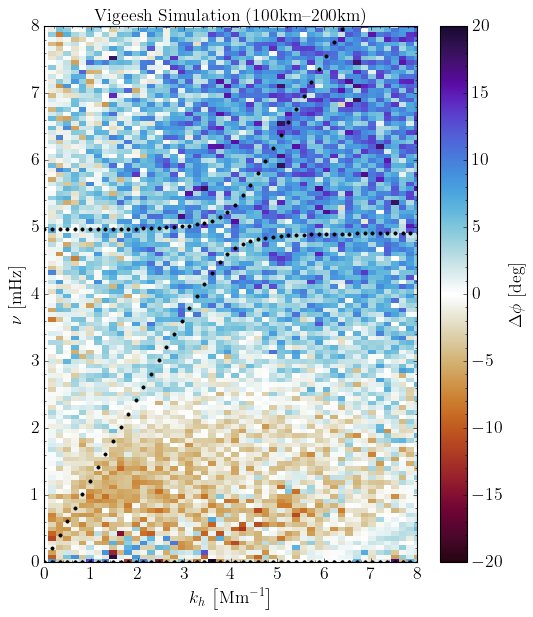

In [8]:
# Calculate phase difference diagrams for a height pair
h1, h2 = '100km', '200km'
phase_diff = diagram(dictionary, h1, h2)

# # Loop through all height pairs
# for pair in pairs:

#     # Heights
#     h1 = str(files[pair[0]].split('/')[-1].split('km')[0].split('_')[-1]) + 'km'
#     h2 = str(files[pair[1]].split('/')[-1].split('km')[0].split('_')[-1]) + 'km'

#     # Calculate phase difference diagram
#     phase_diff = diagram(dictionary, h1, h2)

In [12]:
def time_distance():

    ''' 
    Purpose
    -------
    To compute time-distance diagrams from two atmospheric heights.

    Inputs
    ------
    dict ; dict
        Dictionary containing simulation parameters and Doppler time-series.

    h1 ; str
        Lower height in km.

    h2 ; str
        Higher height in km.

    Outputs
    -------
    time_distance ; np.array, float
        Time-distance diagram.

    Author(s)
    ---------
    Julio M. Morales, October 23rd, 2025
    '''

    # Extract relevant information from the dictionary
    nx, ny, nt = dict[h1]['nx'], dict[h1]['ny'], dict[h1]['nt']
    dx, dy, dt = dict[h1]['dx'], dict[h1]['dy'], dict[h1]['dt']
    v1, v2 = dict[h1]['vz'], dict[h2]['vz']

    # 

In [13]:

def parallel_loop(data, i, box, cen, distance, extent, dx, nrad, nt, bigbox, fullgrid):   

    '''
    '''

    # Unrap the box indices (these are the indices of the center of the annulus)
    indy, indx = np.unravel_index(int(box[i]), bigbox.shape)
        
    # Remove dimensions of size 1
    phi1 = np.squeeze(data[:, indy, indx])

    # Construct the correlation grids to be modified
    phiR = np.zeros((nrad, nt)).astype('complex') # Waves coming from the right
    phiL = np.zeros((nrad, nt)).astype('complex') # Waves coming from the left
    phiT = np.zeros((nrad, nt)).astype('complex') # Waves coming from the top
    phiB = np.zeros((nrad, nt)).astype('complex') # Waves coming from the bottom
    phiA = np.zeros((nrad, nt)).astype('complex') # Waves coming from all directions

    # Loop over annulus indices
    for irad in range(0, int(nrad)):

        # Find indices along the annulus
        x, y = np.nonzero((distance + extent[irad] - dx/2 < fullgrid) & (fullgrid <= distance + extent[irad] + dx/2))

        # Shift the annulus points to the center of the box
        x = (x + indx - cen)
        y = (y + indy - cen)
        
        # Compute the length of the annulus
        nn  = len(x)

        # Value of the cosine and sine functions to be updated
        cosine = np.zeros((nn, 1))
        sine = np.zeros((nn, 1))

        # Construct the array of covariances to be updated
        var = np.zeros((nn, nt)).astype('complex')
        
        # Loop over annulus points
        for j in range(0, int(nn)):

            # Compute the hypotenuse
            hyp = np.hypot(x[j] - indx, y[j] - indy)

            # Compute the cosine and sine functions
            cosine[j] = (x[j] - indx)/hyp
            sine[j] = (y[j] - indy)/hyp
            
            # Update the covariance array
            var[j, :] = np.squeeze(data[:, int(y[j]), int(x[j])])

        # Find pixels within the east quadrant
        inds = (cosine >= 1/np.sqrt(2)).astype(int)
        tmp = np.nonzero(inds == 1)[0]
        phiR[irad, :] = np.squeeze(np.mean(var[tmp, :], axis = 0)).T

        # Find pixels within the west quadrant
        inds = (cosine <= -1/np.sqrt(2)).astype(int)
        tmp = np.nonzero(inds == 1)[0]
        phiL[irad, :] = np.squeeze(np.mean(var[tmp, :], axis = 0)).T

        # Find pixels within the north quadrant
        inds = (sine >= 1/np.sqrt(2)).astype(int)
        tmp = np.nonzero(inds == 1)[0]
        phiT[irad, :] = np.squeeze(np.mean(var[tmp, :], axis = 0)).T

        # Find pixels within the south quadrantt
        inds = (sine <= -1/np.sqrt(2)).astype(int)
        tmp = np.nonzero(inds == 1)[0]
        phiB[irad, :] = np.squeeze(np.mean(var[tmp, :], axis = 0)).T

        # Annulus
        phiA[irad, :] = np.squeeze(np.mean(var, axis = 0)).T

    # Average the cross-correlations within the east quadrant
    phi2 = np.squeeze(np.mean(phiR, axis = 0)).T
    xcorrR = np.fft.ifft(np.conj(phi1)*phi2)

    # Average the cross-correlations within the west quadrant
    phi2 = np.squeeze(np.mean(phiL, axis = 0)).T
    xcorrL = np.fft.ifft(np.conj(phi1)*phi2)
    
    # Average the cross-correlations within the north quadrant
    phi2 = np.squeeze(np.mean(phiT, axis = 0)).T
    xcorrT = np.fft.ifft(np.conj(phi1)*phi2)
    
    # Average the cross-correlations within the south quadrant
    phi2 = np.squeeze(np.mean(phiB, axis = 0)).T
    xcorrB = np.fft.ifft(np.conj(phi1)*phi2)
    
    # Average the cross-correlations within the annulus
    phi2 = np.squeeze(np.mean(phiA, axis = 0)).T
    xcorrA = np.fft.ifft(np.conj(phi1)*phi2)

    return xcorrR, xcorrL, xcorrT, xcorrB, xcorrA

In [14]:
def xcorr(dict, h1, h2, delta):

        '''
        Purpose
        -------
        This function calculates the cross-correlation of Solar dopplergram data using the conventional quadrant method.

        Inputs
        ------
        dict ; dict
            Dictionary containing simulation parameters and Doppler time-series.

        h1 ; str
            Lower height in km.

        h2 ; str
            Higher height in km.

        Outputs
        -------
        xcorr ; np.array, float
            Cross-correlation between two atmospheric heights.

        Author(s)
        ---------
        Julio M. Morales October 23rd, 2025.
        '''

        # Width of the annulus
        dx, width = 1, 0

        # Extract the filtered dopplergram and header
        f_dopplergram = dict[h1]['vz']

        # Extract the time sampling rate and skip distance
        dt = dict[h1]['dt']

        # Extract dimensions of the data
        nt, ny0, nx0 = f_dopplergram.shape

        # Set the maximum size of the box while avoiding edges
        bsize = np.floor((nx0 - 2*delta - 1)/2) - (2*width + 1)

        # Define range of pixels that the width takes up
        extent = list(range(-width, width + 1))

        # Extract length of the range array
        nrad = len(extent)

        # Compute the FFT of the dopplergram along the first axis
        data = np.fft.fft(f_dopplergram, axis = 0)

        if (tile == True):

            # Tile the data if using simulation data
            data = np.tile(data, (3, 3))

            # Define size of the box of usable pixels
            ntarg = nx0
        else:

            # If using real data, define max size of the box of usable pixels
            ntarg = 2*bsize + 1       

        # Define the dimensions of the cross-correlations
        nbox = ntarg*ntarg

        # Extract dimensions of the data
        nt, ny, nx = data.shape
            
        # Center of box (this works for even or odd)
        x0 = np.floor(nx/2)
        y0 = np.floor(ny/2)

        # Find the indices of the box
        x = np.arange(-np.floor(nx / 2), np.floor(nx / 2))
        y = np.arange(-np.floor(ny / 2), np.floor(ny / 2))

        # Construct grid of pixels
        xgrid, ygrid = np.meshgrid(x, y)
        fullgrid = np.hypot(xgrid, ygrid)

        # Find the center of the box
        cen = np.floor(fullgrid.shape[0]/2).astype(int)

        # Define the full box of pixels (usable and not usable)
        bigbox = np.zeros((ny, nx))

        # True if using simulation data
        if (tile == True):

            # Use the full box of pixels
            bigbox[int(nx0 + 1):int(2*nx0 + 1), int(nx0 + 1):int(2*nx0 + 1)] = 1
        else:
            # Use the maximum amount of pixels while avoiding the edges
            bigbox[int(y0 - bsize):int(y0 + bsize + 1), int(x0 - bsize):int(x0 + bsize + 1)] = 1

        # Find the indices of the box
        box = np.nonzero(bigbox.flatten('F') == 1)[0]

        # Define array to store all cross-correlations
        xcorr = np.zeros((5, int(nbox), nt))

        # Parallel loop to compute the cross-correlations
        results = Parallel(n_jobs = -1, require = 'sharedmem')(delayed(parallel_loop)(data, i, box, cen, delta, extent, dx, nrad, nt, bigbox, fullgrid) for i in range(0, int(nbox)))

        # Unpack the results using the * operator and zip function
        xcorr[:] = list(zip(*results))

        # Unpack the results
        xcorrR, xcorrL, xcorrT, xcorrB, xcorrA = xcorr[0], xcorr[1], xcorr[2], xcorr[3], xcorr[4]

        # Get zero frequency element to middle of array and make 3D array
        xcorrR = np.fft.fftshift(xcorrR, 1)
        xcorrR = np.reshape(xcorrR, [int(ntarg), int(ntarg), int(nt)])

        xcorrL = np.fft.fftshift(xcorrL, 1)
        xcorrL = np.reshape(xcorrL, [int(ntarg), int(ntarg), int(nt)])

        xcorrT = np.fft.fftshift(xcorrT, 1)
        xcorrT = np.reshape(xcorrT, [int(ntarg), int(ntarg), int(nt)])

        xcorrB = np.fft.fftshift(xcorrB, 1)
        xcorrB = np.reshape(xcorrB, [int(ntarg), int(ntarg), int(nt)])

        xcorrA = np.fft.fftshift(xcorrA, 1)
        xcorrA = np.reshape(xcorrA, [int(ntarg), int(ntarg), int(nt)])

        return xcorrR, xcorrL, xcorrT, xcorrB, xcorrA